### Examining A Corpus

"A Ball Player's Career" by Adrian C. Anson is a baseball autobiography that (Cap) Anson wrote about his early life, baseball highlights, and managerial career. The corpus, found at https://www.gutenberg.org/cache/epub/19652/pg19652.txt (Project Gutenburg), was published well over 100 years ago and is considered the first baseball biography.

In [2]:
# imports
import requests
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re

After some consideration, the only filtering done was on the added preface from Project Gutenburg which was not part of the original book that Cap Anson wrote. Additionally, there is an appendix after `THE END`. We did not believe these to be important for analyzing the corpus.

In [6]:
# Load corpus and strip out unrelated text
url = 'https://www.gutenberg.org/cache/epub/19652/pg19652.txt'
response = requests.get(url)
response.encoding = 'utf-8'
full_corpus_text = response.text # Use a temporary variable for the full text

start_phrase = 'CHAPTER I. MY BIRTHPLACE AND ANCESTRY.'
end_phrase = 'THE END.'

start_index = full_corpus_text.find(start_phrase)
end_index = full_corpus_text.find(end_phrase)

corpus_text = full_corpus_text # Initialize corpus_text with full content

# Ensure end_phrase appears after start_phrase
# (We manually verified the indices from the original text)
corpus_text = full_corpus_text[start_index : end_index + len(end_phrase)]

print('\n')
print('-----Filtered head of corpus:-----')
print(corpus_text[:500])
print('\n')
print('-----Filtered end of corpus:-----')
print(corpus_text[-500:])



-----Filtered head of corpus:-----
CHAPTER I. MY BIRTHPLACE AND ANCESTRY.

The town of Marshalltown, the county seat of Marshall County, in the
great State of Iowa, is now a handsome and flourishing place of some
thirteen or fourteen thousand inhabitants. I have not had time recently
to take the census myself, and so I cannot be expected to certify
exactly as to how many men, women and children are contained within the
corporate limits.

At the time that I first appeared upon the scene, however, the town was
in a decide


-----Filtered end of corpus:-----
hese prominent characteristics, we
say, Anson stands as the most unique player known in the annals of the
professional fraternity."

This is indeed praise from Sir Hubert, and I raise my hat in
recognition.

What I may conclude to do in the future it is hard to say, and if I
return again to my first love, base-ball, it will not be as a player,
but wherever I may be or whatever I may do I shall still strive to merit
the approval and 

It would be difficult to tell where the cut off points for the preface/appendix, and other extra parts were without first examining the raw text. Those led us to the indices that denote when Cap Anson's own writings began and ended.

In [7]:
# Get tokenizer model to tokenize corpus
nltk.download('punkt_tab', quiet=True)

# Preprocess corpus_text: remove all non-alphabetic characters (keeping spaces)
cleaned_corpus_text = re.sub(r'[^a-zA-Z\s]', '', corpus_text)

# Tokenize the cleaned corpus text
words = word_tokenize(cleaned_corpus_text)
filtered_words = [word.lower() for word in words if word.isalpha()]

# Count unique words
unique_words = set(filtered_words)
total_unique_words = len(unique_words)

print(f'Total unique words: {total_unique_words}')

Total unique words: 8584


 We have 8584 unique words. The corpus building process includes a tokenizer model from `punkt_tab` to split up words and punctuation. Regular expressions were used to get rid of needless punctuation and retain alphabetic words. Words were also set to all lowercase to prevent repeats of the same word such as `the` and `The`. This process limits the corpus to real "unique" words, although it ignores any context regarding the remaining words.

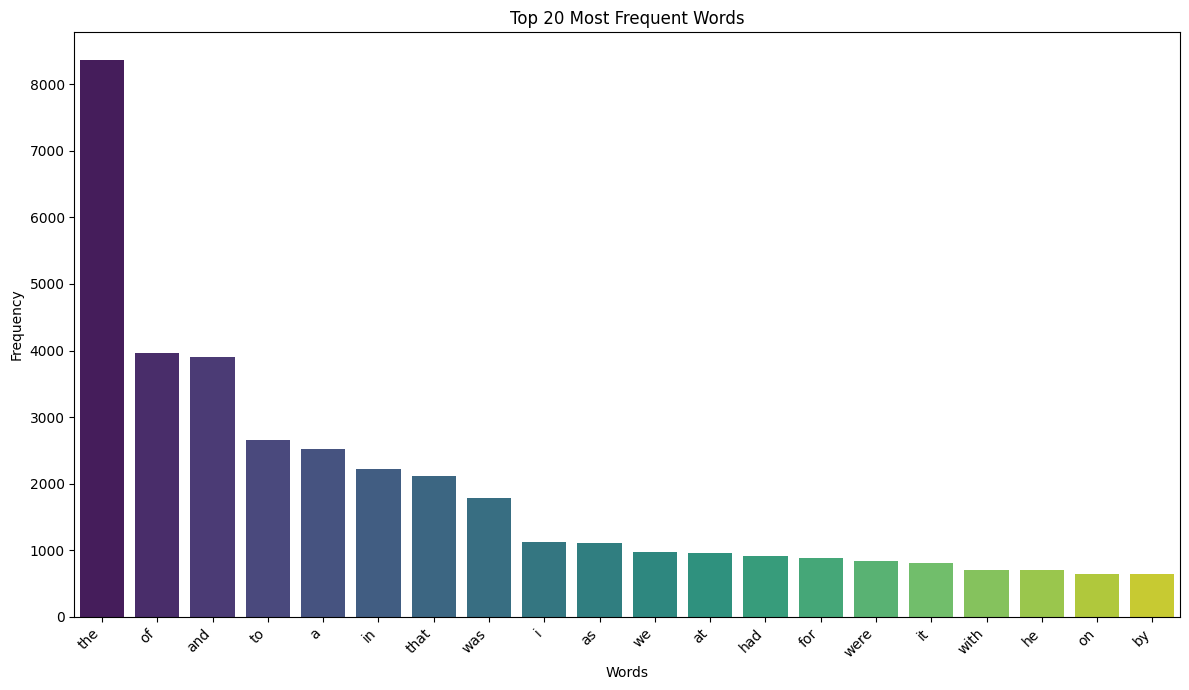

In [8]:
# Calculate word frequencies
fdist = FreqDist(filtered_words)

# Get the 20 most common words and their frequencies
most_common_words = fdist.most_common(20)

# Prepare data for plotting
plot_words, frequencies = zip(*most_common_words)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=list(plot_words), y=list(frequencies), hue=list(plot_words), palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

At a glance, these words are generally what we would consider stopwords. That is fine because they are the actual most common words. We will examine a far greater number of the words as well later on.

In [9]:
# Calculate the total number of words in the filtered corpus
total_words_in_filtered_corpus = len(filtered_words)

# Calculate half of the total words
half_total_words = total_words_in_filtered_corpus / 2

# Initialize variables to track accumulated frequency and unique word count
accumulated_frequency = 0
unique_words_for_half = 0

# Get words and their frequencies, sorted from most common to least common
sorted_word_frequencies = fdist.most_common()

# Iterate through the sorted word frequencies
for word, frequency in sorted_word_frequencies:
    accumulated_frequency += frequency
    unique_words_for_half += 1
    if accumulated_frequency >= half_total_words:
        break

print(f'Total words in filtered corpus: {total_words_in_filtered_corpus}')
print(f'Half of total words: {half_total_words:.0f}')
print(f'Number of unique words representing half of the total words: {unique_words_for_half}')

Total words in filtered corpus: 100935
Half of total words: 50468
Number of unique words representing half of the total words: 61


The amount of words in our baseline corpus is 100935. To get around half of that, we need at least 61 of the most common words. This means a very small percentage of unique words are recurring throughout the corpus.

In [10]:
# Get the 200 most common words and their frequencies
top_200_words = fdist.most_common(200)

print("Top 200 highest frequency words and their counts:")
for i, (word, frequency) in enumerate(top_200_words):
    print(f'{word}: {frequency}')
    if i == 60:
        print('----------------------------------------')
        print('End of first 61 words. The remaining are:')
        print('----------------------------------------')

Top 200 highest frequency words and their counts:
the: 8362
of: 3962
and: 3905
to: 2657
a: 2525
in: 2216
that: 2118
was: 1788
i: 1126
as: 1117
we: 975
at: 961
had: 917
for: 881
were: 838
it: 808
with: 711
he: 697
on: 645
by: 639
but: 463
not: 456
one: 454
which: 448
my: 428
be: 421
our: 414
game: 411
from: 407
his: 401
time: 382
being: 373
been: 363
have: 351
all: 340
who: 339
they: 339
is: 333
us: 325
this: 317
when: 308
an: 294
there: 289
chicago: 247
club: 247
ball: 245
after: 235
made: 235
so: 231
up: 231
their: 226
some: 224
them: 222
me: 221
first: 208
would: 208
him: 208
out: 202
good: 201
than: 197
players: 197
----------------------------------------
End of first 61 words. The remaining are:
----------------------------------------
played: 192
team: 186
then: 185
where: 181
while: 178
could: 175
its: 172
before: 171
season: 171
over: 170
games: 169
baseball: 162
league: 162
day: 160
no: 158
new: 155
more: 154
great: 153
most: 142
both: 141
many: 137
upon: 137
did: 137
came: 13

We marked where the 61st word was so that we would know where the halfway point of all words within the corpus was. While there were still some generic words such as `its` below that line, we also saw a few interesting ones above such as `game`, `ball`, and `chicago`.

The unique word creation process resulted in a few "issues" such as `st` and `th` being listed as words. They might be reduced versions of words such as first, fourth, or fifth in the form of: `1st`, `4th`, `5th`. We will leave it as is in this case because the appropriate way to account for them requires far more analysis. As long as they represent actual meaningful words within the corpus, they are useful in their current form.

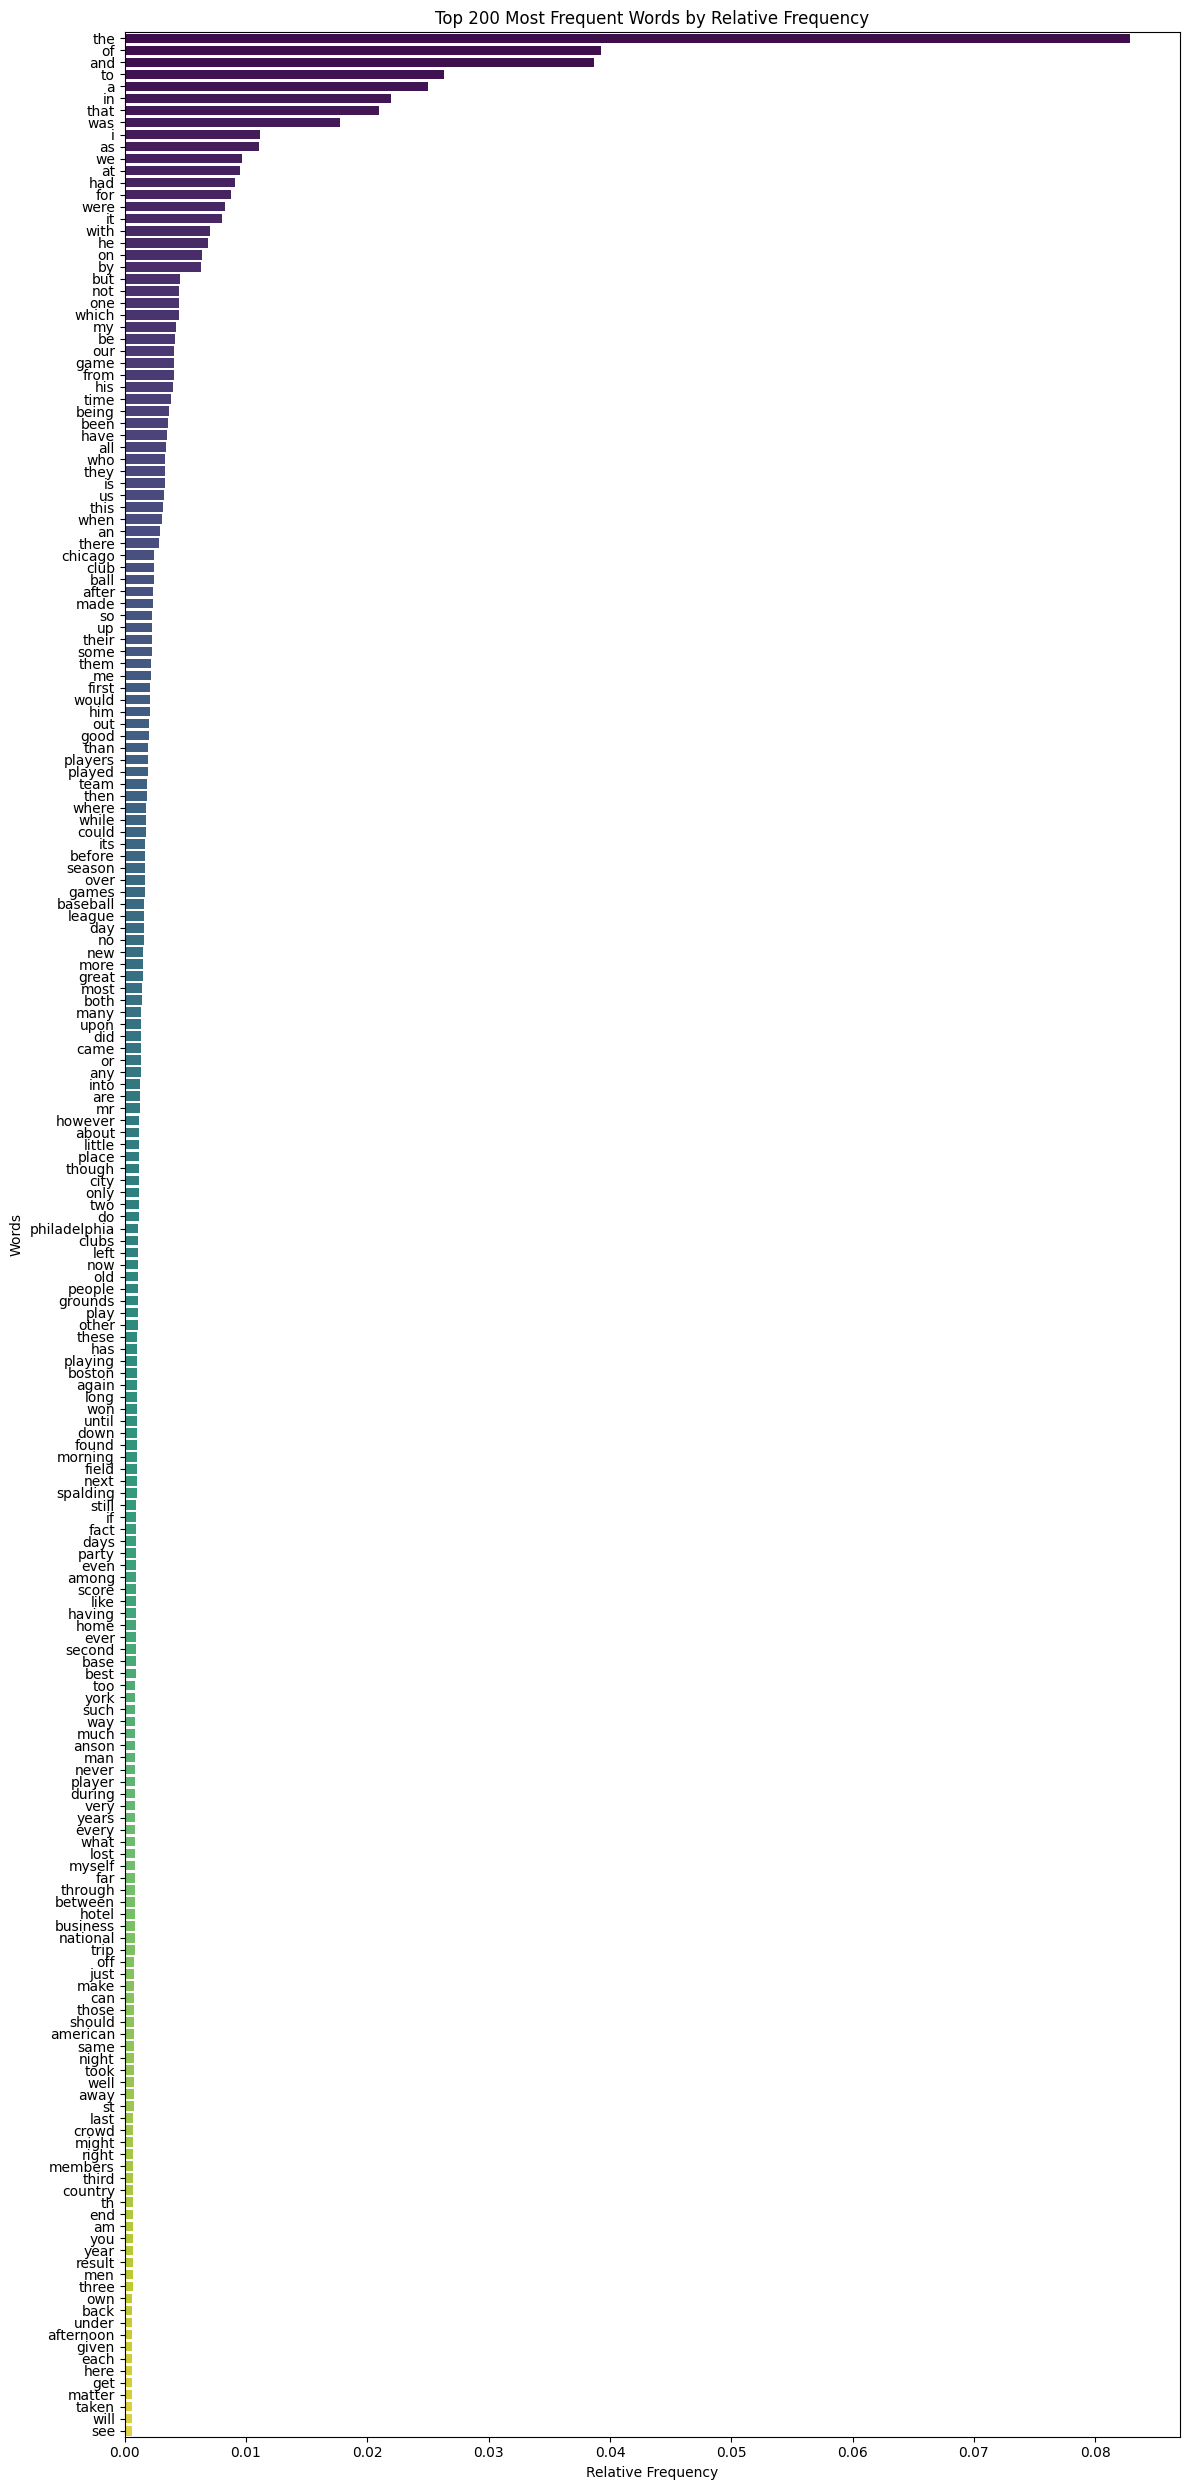

In [22]:
df_top_words = pd.DataFrame(top_200_words, columns=['Word', 'Frequency'])

if 'Relative Frequency' not in df_top_words.columns:
    df_top_words['Relative Frequency'] = df_top_words['Frequency'] / total_words_in_filtered_corpus

# Create a bar chart for relative frequencies of all 200 words
plt.figure(figsize=(12, 25)) # Increased height significantly for horizontal bars
sns.barplot(x='Relative Frequency', y='Word', data=df_top_words, hue='Word', palette='viridis', legend=False)
plt.title('Top 200 Most Frequent Words by Relative Frequency')
plt.xlabel('Relative Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

`The` occurred twice as frequently as the next most common word `of`. While `and` has a small dropoff, we generally get a frequency halving akin to that of Zipf's Law.

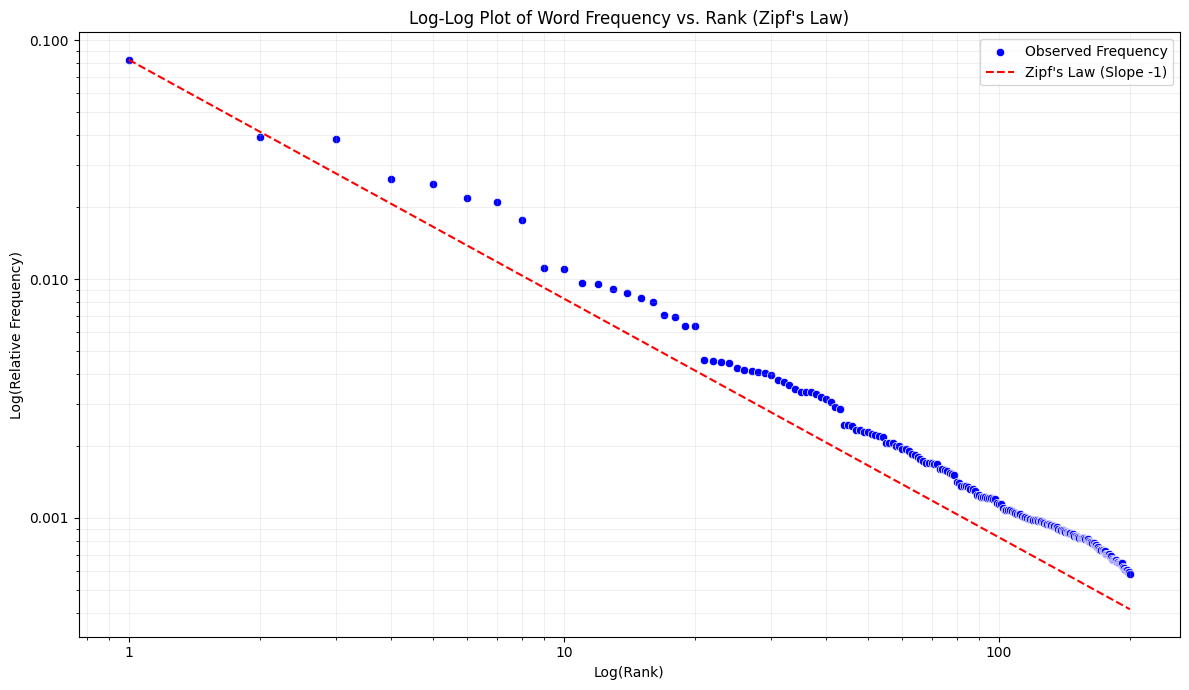

In [27]:
import matplotlib.ticker as ticker

# Plotting observed relative frequencies vs. rank on a log-log scale
df_top_words['Rank'] = df_top_words.index + 1

# Calculate the expected relative frequency according to Zipf's Law
# Get the relative frequency of the most common word (rank 1)
relative_freq_rank_1 = df_top_words.loc[0, 'Relative Frequency']
df_top_words['Zipf_Expected_Relative_Frequency'] = relative_freq_rank_1 / df_top_words['Rank']

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_top_words,
    x='Rank',
    y='Relative Frequency',
    label='Observed Frequency',
    color='blue'
)

sns.lineplot(
    x=df_top_words['Rank'],
    y=df_top_words['Zipf_Expected_Relative_Frequency'],
    label='Zipf\'s Law (Slope -1)',
    color='red',
    linestyle='--'
)
# Handle log
plt.xscale('log')
plt.yscale('log')

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

ax.grid(True, which="both", ls="-", alpha=0.2)

plt.title('Log-Log Plot of Word Frequency vs. Rank (Zipf\'s Law)')
plt.xlabel('Log(Rank)')
plt.ylabel('Log(Relative Frequency)')
plt.legend()
plt.tight_layout()
plt.show()

The idea of Zipf's Law is that a corpus will typically have an inverse log relationship between word rank and relative frequency.

This corpus as a whole appears to follow Zipf's Law. The red line represents the expected -1 slope to compare to. While the relative frequencies are not all directly on said line, they follow a general downward linear trend.

### Comparing This Corpus to the Whole

Let's peek at the top 200 words without stopwords to make it easier to see what unique words occurred frequently in this corpus. We will reference both the corpus with and without stopwords when estimating how this corpus compares to all texts in existence.

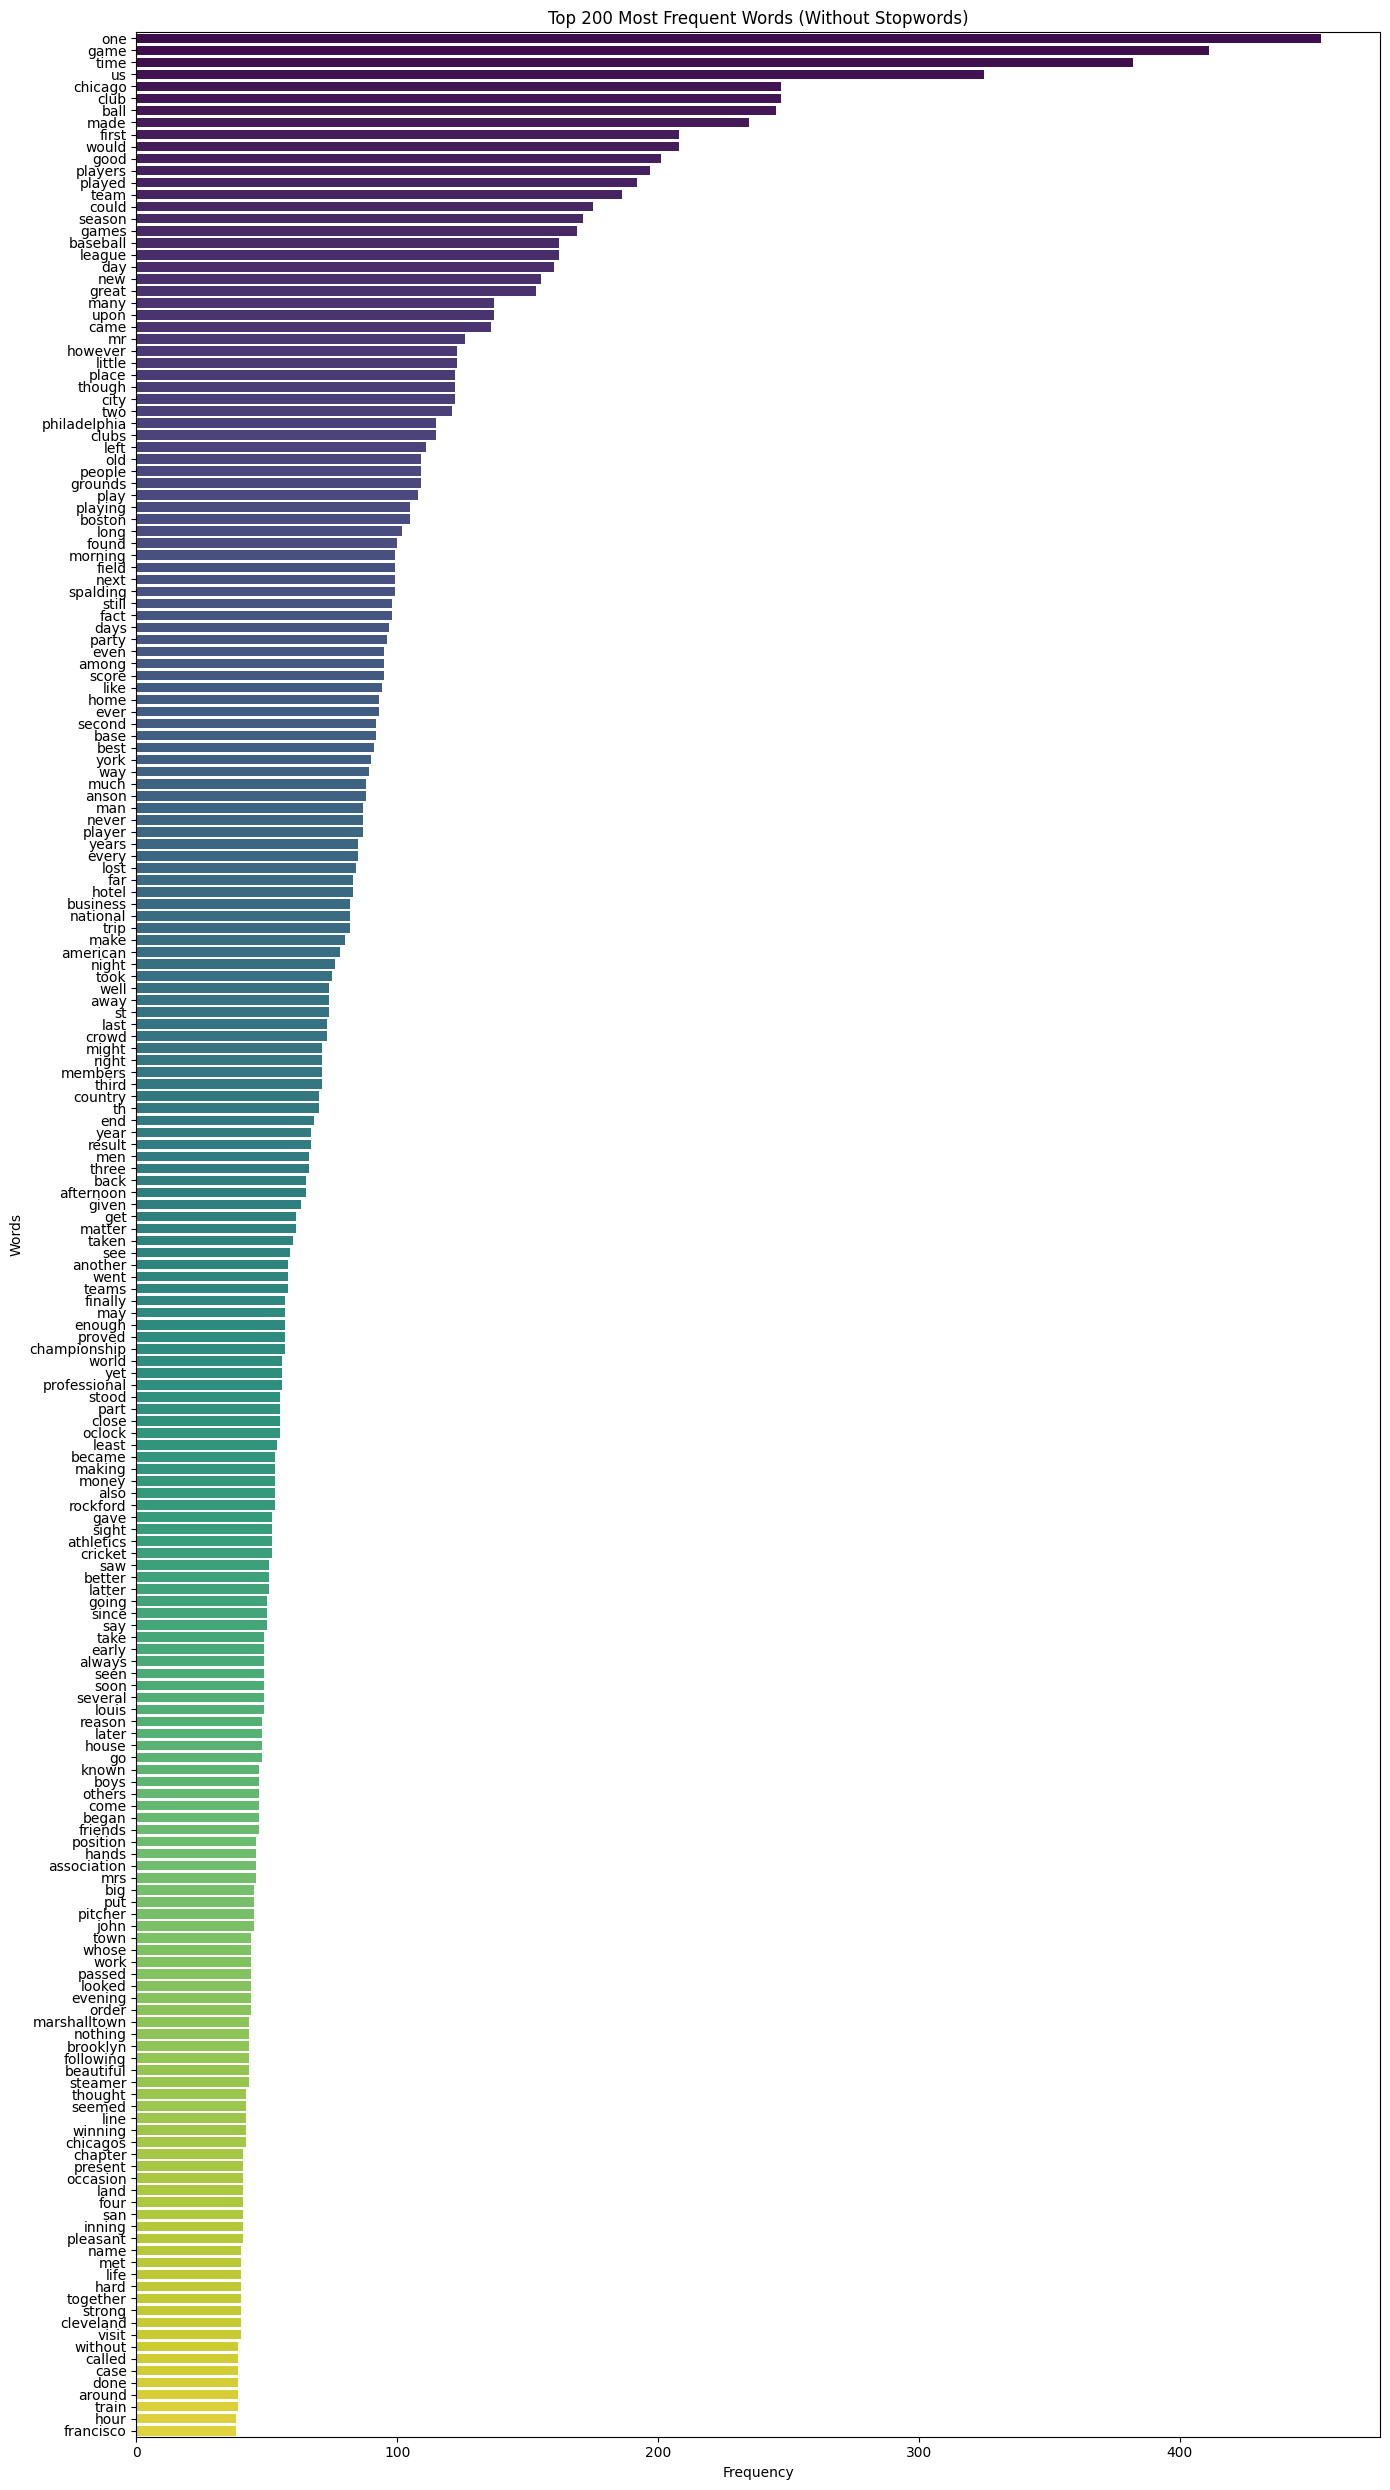

In [17]:
# Download stopwords
nltk.download('stopwords', quiet=True)

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Filter out stopwords from the 'filtered_words' list
filtered_words_no_stopwords = [word for word in filtered_words if word not in stop_words]

# Calculate frequency distribution for words without stopwords
fdist_no_stopwords = FreqDist(filtered_words_no_stopwords)

# Get the 100 most common words without stopwords
top_200_words_no_stopwords = fdist_no_stopwords.most_common(200)

# Prepare data for plotting
plot_words_no_stopwords, frequencies_no_stopwords = zip(*top_200_words_no_stopwords)

# Create a bar chart for the top 200 words without stopwords
plt.figure(figsize=(14, 25)) # Increased height for better readability
sns.barplot(x=list(frequencies_no_stopwords), y=list(plot_words_no_stopwords), hue=list(plot_words_no_stopwords), palette='viridis', legend=False)
plt.title('Top 200 Most Frequent Words (Without Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

Compared to "all words in all corpora" the general frequencies of words appears to be very similar and representative. However, if we were to dig deeper, we can identify a few key potential differences:

* This is Cap Anson's autobiography. Unless the baseball player is Rickey Henderson (notorious for speaking in the third person), we can expect the autobiography to use first person such as "I" more frequently than the average text. It is for this reason we should not remove stopwords haphazardly. They are not always meaningless.
* As a baseball player who wrote about his baseball days, we would expect to see baseball related terms as we previously alluded to such as "game", "player", "ball", and "league". Even while keeping stopwords, we could see the importance of baseball related words in the top 200.
* Some other terms specific to Anson were more prominent such as "Anson", "Chicago", and "American". Unsurprisingly, Anson's spent 22 years of his baseball career in Chicago. Other cities such as  "Philadelphia" and "Boston" must have also been important in his life.
* The corpus without stopwords also highlight the words `york` and `francisco`. These are likely short for New York and San Francisco. This suggests the possibility of full "words" having spaces in them. While there are common combinations of words that are effectively one word, Anson would've had his own unique set of such words in his vocabulary. Depending on context, there could be a person named Francisco that was frequently mentioned instead.
* While we don't have specific examples here, the late 1890s to early 1900s era when this was written may have some unique word usage frequencies. This may even affect the rankings of more generic stopwords.

### Conclusions

Cap Anson's autobiography was a reflection of who he was and when he wrote it. We can discern that he was a baseball player in Chicago with just his most frequently used words. His word usage followed Zipf's Law fairly well. This means it has a predictable vocabulary usage and makes it a solid corpus for high frequency analysis. There is potential for analysis regarding words Anson chunked together in his book.

Presentation link: https://www.youtube.com/watch?v=xgnCp5UHZ9I